In [12]:
import polars as pl
import matplotlib.pyplot as plt
from tabulate import tabulate

## Read the dataset, check contents and basic stats

In [54]:
counts = (
    pl.scan_parquet("../data/yellow_tripdata_2026-0[1-2].parquet")
    .select(pl.len().alias("Count"))
    .collect()
)

# Display the number of records
display(counts)

# Display the first 5 records
df = (
    pl.scan_parquet("../data/yellow_tripdata_2026-0[1-2].parquet")
    .head(5)
    .collect()
)

df

Count
u32
7124755


VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,"""N""",239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.9,1,"""N""",163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75
1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.4,1,"""N""",43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75
2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,"""N""",142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,"""N""",88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75


In [53]:
filtered_count = (
    pl.scan_parquet("../data/yellow_tripdata_2026-0[1-2].parquet")
    .filter(
        (pl.col("fare_amount") > 20)
        & (pl.col("tip_amount") > 3)
        & (pl.col("trip_distance") > 2)
    )
    .select(pl.len().alias("matching_rides"))
    .collect()
)

display(filtered_count)


matching_rides
u32
883596


## Explore the common and different columns between the yellow and grenn cab datasets

In [7]:
yellow_cols = pl.scan_parquet("../data/yellow_tripdata_2026-01.parquet").collect_schema().names()
green_cols = pl.scan_parquet("../data/green_tripdata_2026-01.parquet").collect_schema().names()

print("Only in Yellow")
print(set(yellow_cols) - set(green_cols))
print()

print("Only in Green")
print(set(green_cols) - set(yellow_cols))
print()

print("Common to both")
print(set(yellow_cols).intersection(set(green_cols)))

Only in Yellow
{'Airport_fee', 'tpep_dropoff_datetime', 'tpep_pickup_datetime'}

Only in Green
{'lpep_pickup_datetime', 'ehail_fee', 'trip_type', 'lpep_dropoff_datetime'}

Common to both
{'total_amount', 'mta_tax', 'congestion_surcharge', 'VendorID', 'fare_amount', 'RatecodeID', 'extra', 'payment_type', 'tip_amount', 'PULocationID', 'store_and_fwd_flag', 'cbd_congestion_fee', 'trip_distance', 'DOLocationID', 'tolls_amount', 'improvement_surcharge', 'passenger_count'}


## Union of Yellow and Green Taxi Data

In [57]:
yellow_df = pl.scan_parquet("../data/yellow_tripdata_2026-01.parquet")
green_df = pl.scan_parquet("../data/green_tripdata_2026-01.parquet")

combined_df = pl.concat(
    [
        yellow_df,
        green_df
    ],
    how="diagonal"
)

combined_df.head(5).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,lpep_pickup_datetime,lpep_dropoff_datetime,ehail_fee,trip_type
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],datetime[μs],f64,i64
2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,"""N""",239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0,null,null,null,null
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.9,1,"""N""",163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75,null,null,null,null
1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.4,1,"""N""",43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75,null,null,null,null
2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,"""N""",142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,null,null,null,null
2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,"""N""",88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75,null,null,null,null


## Explore the location ID reference data

In [8]:
pl.scan_parquet("../data/yellow_tripdata_2026-01.parquet").head(5).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
i32,datetime[μs],datetime[μs],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,"""N""",239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.0
1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.9,1,"""N""",163,162,2,7.9,4.25,0.5,0.0,0.0,1.0,13.65,2.5,0.0,0.75
1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.4,1,"""N""",43,237,1,10.7,4.25,0.5,2.5,0.0,1.0,18.95,2.5,0.0,0.75
2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,"""N""",142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,"""N""",88,144,1,13.5,1.0,0.5,3.85,0.0,1.0,23.1,2.5,0.0,0.75


## Now let's create two functions that can return scanned dataframes
1. get_data: Taxi Rides Data
2. get_location_lookup_data: Location reference data

In [9]:
from pathlib import Path

def get_data(
    taxi_type: str,
    year: int,
    month: int|list[int]|None = None
) -> pl.LazyFrame:
    months = list(range(1, 13)) if month is None else ([month] if isinstance(month, int) else month)
    if not months:
        raise ValueError("month must not be empty")

    invalid_months = [m for m in months if not 1 <= m <= 12]
    if invalid_months:
        raise ValueError(f"Invalid month values: {invalid_months}")

    file_names = [
        f"../data/{taxi_type}_tripdata_{year:04d}-{m:02d}.parquet"
        for m in months
    ]
    missing_files = [file_name for file_name in file_names if not Path(file_name).exists()]
    if missing_files:
        raise ValueError(f"Files not found: {missing_files}")

    source = file_names[0] if len(file_names) == 1 else file_names
    return pl.scan_parquet(source)

def get_location_lookup_data() -> pl.DataFrame:
    return pl.scan_csv("../data/taxi_zone_lookup.csv")


## Explore rides by hour

In [19]:
import time

st = time.time()

df_rides_by_hour = (
    # Get Rides dataset for yellow cab, year 2026, month 1
    get_data("yellow", 2026, [1,2])

    # Derive the hour column from the tpep_pickup_datetime column
    .with_columns(
        pl.col("tpep_pickup_datetime").dt.hour().alias("hour")
    )

    # Group the dataset by hour
    .group_by("hour")

    # Aggregate functions (In this case pl.len() counts the occurences per group
    .agg(
        pl.len().alias("rides")
    )

    # Now compute the percentage of rides from rides
    .with_columns(
        (pl.col("rides") / pl.col("rides").sum() * 100).round(2).alias("pct_of_rides")
    )

    # Sort the result by hour
    .sort("hour")

    # Collect the results in memory for display and downstream use
    .collect()
)

elapsed = time.time() - st
print(f"Time elapsed = {elapsed:5.3f}")

with pl.Config(tbl_rows=24):
    display(df_rides_by_hour)

Time elapsed = 0.039


hour,rides,pct_of_rides
i8,u32,f64
0,212641,2.98
1,145109,2.04
2,100048,1.4
3,71910,1.01
4,56913,0.8
5,64375,0.9
6,125116,1.76
7,219057,3.07
8,286028,4.01


### Plot

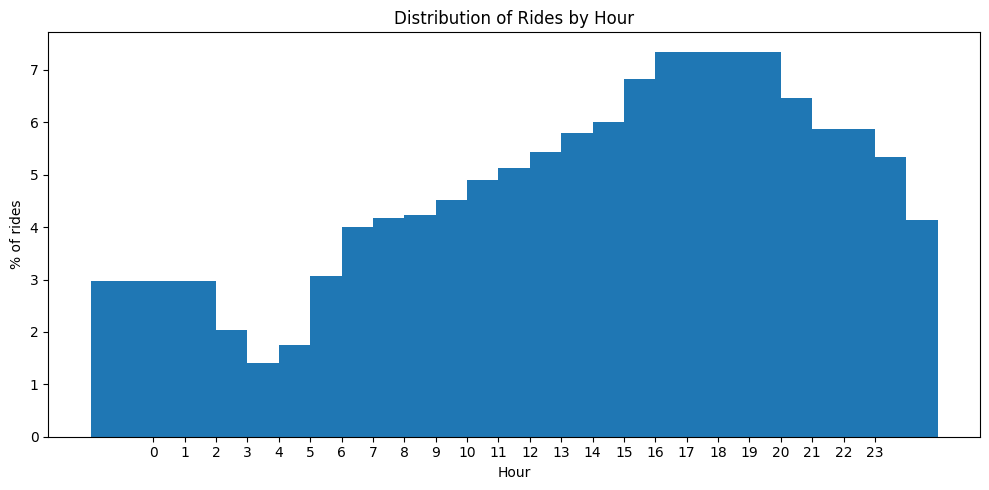

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(
    df_rides_by_hour["hour"].to_list(),
    df_rides_by_hour["pct_of_rides"].to_list(),
    width=4,
)
plt.xlabel("Hour")
plt.ylabel("% of rides")
plt.title("Distribution of Rides by Hour")
plt.xticks(df_rides_by_hour["hour"].to_list())
plt.tight_layout()
plt.show()

## Explore rides by pickup-point, dropoff-point

In [21]:
df_rides_by_pp = (
    get_data("yellow", 2026, 1)
    .join(
        get_location_lookup_data(),
        left_on="PULocationID",
        right_on="LocationID"
    )
    .join(
        get_location_lookup_data(),
        left_on="DOLocationID",
        right_on="LocationID"
    )
    .rename(
        {
            "Borough": "Pick-Up",
            "Borough_right": "Drop-Off"
        }
    )
    .group_by("Pick-Up", "Drop-Off")
    .agg(
        pl.len().alias("rides")
    )
    .with_columns(
        (pl.col("rides") / pl.col("rides").sum() * 100).round(2).alias("pct_of_rides")
    )
    .sort("pct_of_rides", descending=[True])
    .collect()
)

df_rides_by_pp

Pick-Up,Drop-Off,rides,pct_of_rides
str,str,u32,f64
"""Manhattan""","""Manhattan""",2959577,79.45
"""Queens""","""Manhattan""",162216,4.35
"""Queens""","""Queens""",107724,2.89
"""Manhattan""","""Brooklyn""",93541,2.51
"""Manhattan""","""Queens""",84167,2.26
…,…,…,…
"""Staten Island""","""Bronx""",5,0.0
"""Staten Island""","""N/A""",2,0.0
"""Unknown""","""EWR""",5,0.0


## Explore tipping behavior

1. Choose a dataset
2. Filter for data where there was a fare amount (this is just a base check)
3. Calculate a Tip Pct column and put it in buckets of 5,10,15,20,....
4. Then Group the the Bucket and show the Pct of trips for that bucket

In [22]:
result = (
    get_data("yellow", 2026, 1)
    .filter(pl.col("fare_amount") > 0)
    .with_columns(
        (((pl.col("tip_amount") / pl.col("fare_amount")) * 100) / 5)
        .round()
        .mul(5)
        .alias("tip_pct_bucket")
    )
    .group_by("tip_pct_bucket")
    .agg(pl.len().alias("rides"))
    .with_columns(
        (pl.col("rides") / pl.col("rides").sum() * 100).round(2).alias("pct_of_rides")
    )
    .sort("tip_pct_bucket")
    .collect()
)

with pl.Config(tbl_rows=min(50, result.height)):
    display(result)


tip_pct_bucket,rides,pct_of_rides
f64,u32,f64
0.0,1564387,42.47
5.0,52603,1.43
10.0,119474,3.24
15.0,171678,4.66
20.0,196844,5.34
25.0,554105,15.04
30.0,510536,13.86
35.0,257824,7.0
40.0,139513,3.79


### Plot

tip_pct_bucket,rides,pct_of_rides
f64,u32,f64
0.0,1564387,42.47
5.0,52603,1.43
10.0,119474,3.24
15.0,171678,4.66
20.0,196844,5.34
25.0,554105,15.04
30.0,510536,13.86
35.0,257824,7.0
40.0,139513,3.79


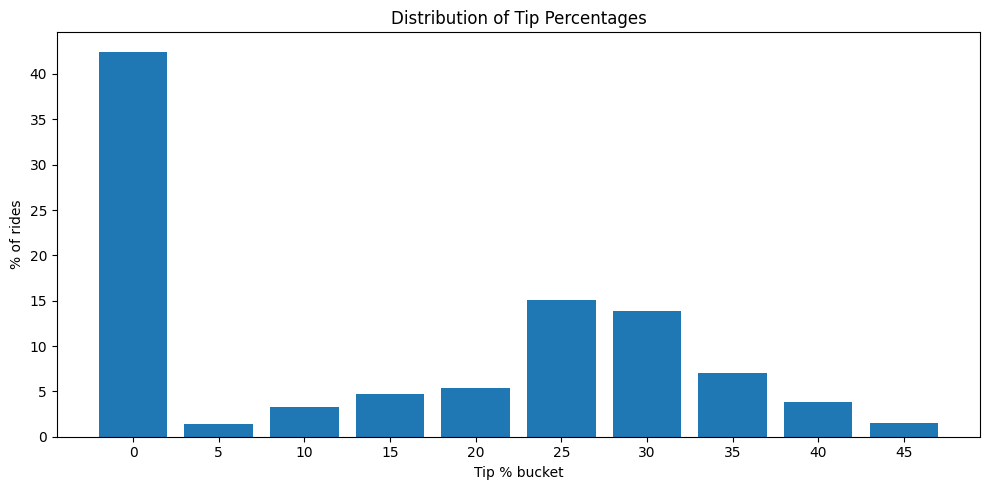

In [23]:
import matplotlib.pyplot as plt

result_plot = result.filter(pl.col("pct_of_rides") > 1)
display(result_plot)
plt.figure(figsize=(10, 5))
plt.bar(
    result_plot["tip_pct_bucket"].to_list(),
    result_plot["pct_of_rides"].to_list(),
    width=4,
)
plt.xlabel("Tip % bucket")
plt.ylabel("% of rides")
plt.title("Distribution of Tip Percentages")
plt.xticks(result_plot["tip_pct_bucket"].to_list())
plt.tight_layout()
plt.show()

In [ ]:
pl.sca